<a href="https://colab.research.google.com/github/belacile/PortfolioWebsite/blob/main/Nexus/Model_Training/MVP2/Demo2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

import numpy as np

import pandas as pd
from sklearn.metrics import confusion_matrix

import os
from PIL import Image
import json

import h5py

In [2]:
from google.colab import drive
drive.mount('/content/drive')

payload_dir = '/content/drive/My Drive/Demo2_Data'

dir_list = os.listdir(payload_dir)

Mounted at /content/drive


In [3]:
# Data Info

# Image dimensions
IMG_WIDTH = 640
IMG_HEIGHT = 480
IMG_CHS = 3

# YOLO Feature Size (6 per max expected objects)
YOLO_FEATURE_SIZE = 150 # 600 -> 100 max expected objects

# LiDAR points per second (20 frames per second)
POINTS_PER_SECOND = 100000 # 100000 -> 5000 max expected arrays of [x,y,z,i]
FPS = 20 # Frames per second
POINTS_PER_FRAME = POINTS_PER_SECOND // FPS # Points per frame
LIDAR_CHS = 3 # Assuming 3 channels: height, intensity, density
LIDAR_GRID_WIDTH = 256 # LiDAR grid width
LIDAR_GRID_HEIGHT = 256 # LiDAR grid height
INCLUDE_LIDAR = True # Whether to include LiDAR data in output

# Choosing the processor
PROCESSOR = 'cuda' # set to 'cpu' or 'cuda'

In [4]:
# HDF5 Dataset
class HDF5Dataset(Dataset):
    def __init__(self, hdf5_files, transform=None, include_lidar=False):
        """
        Args:
            hdf5_files (list): List of HDF5 file paths generated by DataGen.py
            transform (callable, optional): Optional transform to be applied on images
            include_lidar (bool): Whether to include LiDAR data in output (for future use)
        """
        self.hdf5_files = hdf5_files
        self.transform = transform
        self.include_lidar = include_lidar
        self.samples = []

        # Build list of (file_path, frame_index) tuples for all samples
        for hdf5_file in hdf5_files:
            try:
                with h5py.File(hdf5_file, 'r') as f:
                    num_frames = f.attrs['num_frames']
                    for frame_idx in range(num_frames):
                        self.samples.append((hdf5_file, frame_idx))
                print(f"Loaded {num_frames} frames from {os.path.basename(hdf5_file)}")
            except Exception as e:
                print(f"Warning: Could not load {hdf5_file}: {e}")

        # Define LiDAR grid parameters (example values, adjust as needed)
        self.lidar_grid_width = 256  # Number of cells in width
        self.lidar_grid_height = 256 # Number of cells in height
        self.lidar_x_range = (-20, 20) # Meters
        self.lidar_y_range = (0, 40) # Meters (forward direction)
        self.lidar_z_range = (-2, 5) # Meters (height)

        self.lidar_x_cell_size = (self.lidar_x_range[1] - self.lidar_x_range[0]) / self.lidar_grid_width
        self.lidar_y_cell_size = (self.lidar_y_range[1] - self.lidar_y_range[0]) / self.lidar_grid_height


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        hdf5_file, frame_idx = self.samples[idx]

        with h5py.File(hdf5_file, 'r') as f:
            # Load image (already in RGB format from DataGen.py)
            image = f['images'][frame_idx]  # Shape: (480, 640, 3)
            image = Image.fromarray(image.astype(np.uint8))

            if self.transform:
                image = self.transform(image)

            # Load pre-processed YOLO features (already in correct format)
            yolo_features = torch.from_numpy(f['yolo_features'][frame_idx]).float()

            # Load label
            label = float(f['labels'][frame_idx])

            if self.include_lidar:
                # Convert raw points to 2D BEV grid
                lidar_grid = np.zeros((self.lidar_grid_height, self.lidar_grid_width, 3), dtype=np.float32) # Example: height, intensity, density

                # Check if 'lidar_points_data' dataset exists before trying to load it
                if 'lidar_points_data' in f:
                    # Load raw LiDAR data
                    # LiDAR points are stored in 'lidar_points_data' as flattened arrays
                    # and have a shape like (num_points, 4) per frame [x, y, z, intensity]
                    lidar_points = f['lidar_points_data'][frame_idx] # Returns a numpy array

                    # Reshape from flattened to (N, 4) if there are points
                    if len(lidar_points) > 0:
                        lidar_points = lidar_points.reshape(-1, 4)
                    else:
                        lidar_points = np.zeros((0, 4), dtype=np.float32)

                    if lidar_points.shape[0] > 0: # Process only if there are points
                        # Filter points within the defined range
                        mask = (lidar_points[:, 0] >= self.lidar_x_range[0]) & (lidar_points[:, 0] < self.lidar_x_range[1]) & \
                               (lidar_points[:, 1] >= self.lidar_y_range[0]) & (lidar_points[:, 1] < self.lidar_y_range[1]) & \
                               (lidar_points[:, 2] >= self.lidar_z_range[0]) & (lidar_points[:, 2] < self.lidar_z_range[1])
                        filtered_points = lidar_points[mask]

                        if filtered_points.shape[0] > 0:
                            # Map points to grid cell coordinates
                            grid_x = ((filtered_points[:, 0] - self.lidar_x_range[0]) / self.lidar_x_cell_size).astype(np.int32)
                            grid_y = ((filtered_points[:, 1] - self.lidar_y_range[0]) / self.lidar_y_cell_size).astype(np.int32)

                            # Ensure grid coordinates are within bounds (should be handled by filtering, but good practice)
                            grid_x = np.clip(grid_x, 0, self.lidar_grid_width - 1)
                            grid_y = np.clip(grid_y, 0, self.lidar_grid_height - 1)

                            # Populate grid cells - Example: Store max height, max intensity, and point count
                            for i in range(filtered_points.shape[0]):
                                x, y, z, intensity = filtered_points[i]
                                gx, gy = grid_x[i], grid_y[i]

                                # Max height in the cell
                                lidar_grid[gy, gx, 0] = max(lidar_grid[gy, gx, 0], z)
                                # Max intensity in the cell
                                lidar_grid[gy, gx, 1] = max(lidar_grid[gy, gx, 1], intensity)
                                # Point count in the cell
                                lidar_grid[gy, gx, 2] += 1

                            # Normalize point count (optional, but can help)
                            # max_points = np.max(lidar_grid[:, :, 2])
                            # if max_points > 0:
                            #     lidar_grid[:, :, 2] /= max_points


                # Convert numpy grid to PyTorch tensor and rearrange dimensions to [channels, height, width]
                lidar_grid_tensor = torch.from_numpy(lidar_grid).permute(2, 0, 1).float()


                return image, yolo_features, lidar_grid_tensor, label
            else:
                # Return same format as original SimulationDataset
                return image, yolo_features, label

In [5]:
# Keep the original SimulationDataset for backward compatibility
class SimulationDataset(Dataset):
    def __init__(self, dir_list, root_dir='/content/drive/My Drive/DemoTest', transform=None):
        """
        Args:
            dir_list (list): List of directories containing simulation data.
            root_dir (string): Directory with all the simulation directories.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.root_dir = root_dir
        self.dir_list = dir_list
        self.transform = transform
        self.samples = []

        # Build a list of (image_file_path, json_file_path) tuples for all samples
        for sim_dir in self.dir_list:
            sim_path = os.path.join(self.root_dir, sim_dir)
            if os.path.isdir(sim_path):
                # Assuming image and json files have the same base name
                file_names = [f.split('.')[0] for f in os.listdir(sim_path) if os.path.isfile(os.path.join(sim_path, f))]
                unique_names = sorted(list(set(file_names))) # Get unique base names and sort them


                for name in unique_names:
                    # Use the provided naming convention
                    img_path = os.path.join(sim_path, f"{name}.png")
                    json_path = os.path.join(sim_path, f"{name}.json")

                    if os.path.exists(img_path) and os.path.exists(json_path):
                        self.samples.append((img_path, json_path))
                    else:
                        print(f"Warning: Missing image or json for sample {name} in {sim_dir}")


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, json_path = self.samples[idx]

        # Load image
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # Load and process JSON (YOLO) data
        with open(json_path, 'r') as f:
            yolo_data = json.load(f)

        # Extract the label (collision) and convert to float
        # BCEWithLogitsLoss expects float targets
        label = float(yolo_data.get("collision", False)) # Get collision status, default to False if not present

        # Process bboxes into a fixed-size feature vector
        bboxes = yolo_data.get("bboxes", [])
        processed_yolo_data = torch.zeros(YOLO_FEATURE_SIZE) # Initialize with zeros

        # Assume YOLO_FEATURE_SIZE is designed to hold flattened bbox data (e.g., 100 objects * 6 features)
        bbox_features = []
        for bbox in bboxes[:YOLO_FEATURE_SIZE // 6]: # Process up to the maximum number of objects
            # Include the encoded 'class' integer
            encoded_class = bbox.get("class", 0) # Assuming the class is already encoded to an integer, default to 0 if not present
            bbox_features.extend([encoded_class, bbox.get("conf", 0.0), bbox.get("x1", 0.0), bbox.get("y1", 0.0), bbox.get("x2", 0.0), bbox.get("y2", 0.0)])

        # Pad with zeros if less than YOLO_FEATURE_SIZE features are extracted
        # Ensure the tensor is float to match the model's output expectations for BCEWithLogitsLoss
        processed_yolo_data[:len(bbox_features)] = torch.tensor(bbox_features).float()


        return image, processed_yolo_data, label

In [6]:
# Example: How to use HDF5Dataset with files from DataGen.py

# Find all HDF5 files in your payload directory
hdf5_files = []

if os.path.exists(payload_dir):
    for file in os.listdir(payload_dir):
        if file.endswith('.h5'):
            hdf5_files.append(os.path.join(payload_dir, file))

    print(f"Found {len(hdf5_files)} HDF5 files:")
    for file in hdf5_files:
        print(f"  - {file}")
else:
    print(f"Directory {payload_dir} not found. Please update the path to your HDF5 files.")
    print("Example usage:")
    print("  hdf5_files = ['payload/sim_1.h5', 'payload/sim_2.h5', ...]")
    hdf5_files = []  # Empty list for now

# Note: data_transform will be defined in the next cell
print(f"\nHDF5 files ready for loading: {len(hdf5_files)} files found")


Found 20 HDF5 files:
  - /content/drive/My Drive/Demo2_Data/sim_1.h5
  - /content/drive/My Drive/Demo2_Data/sim_2.h5
  - /content/drive/My Drive/Demo2_Data/sim_3.h5
  - /content/drive/My Drive/Demo2_Data/sim_4.h5
  - /content/drive/My Drive/Demo2_Data/sim_5.h5
  - /content/drive/My Drive/Demo2_Data/sim_6.h5
  - /content/drive/My Drive/Demo2_Data/sim_7.h5
  - /content/drive/My Drive/Demo2_Data/sim_8.h5
  - /content/drive/My Drive/Demo2_Data/sim_9.h5
  - /content/drive/My Drive/Demo2_Data/sim_10.h5
  - /content/drive/My Drive/Demo2_Data/sim_11.h5
  - /content/drive/My Drive/Demo2_Data/sim_12.h5
  - /content/drive/My Drive/Demo2_Data/sim_13.h5
  - /content/drive/My Drive/Demo2_Data/sim_14.h5
  - /content/drive/My Drive/Demo2_Data/sim_15.h5
  - /content/drive/My Drive/Demo2_Data/sim_16.h5
  - /content/drive/My Drive/Demo2_Data/sim_17.h5
  - /content/drive/My Drive/Demo2_Data/sim_18.h5
  - /content/drive/My Drive/Demo2_Data/sim_19.h5
  - /content/drive/My Drive/Demo2_Data/sim_20.h5

HDF5 fi

In [7]:
# Hyperparameters

# Step Size
LEARNING_RATE = 0.001 # Adam's default is 0.001
# L2 Regularlization
WEIGHT_DECAY = 0.0001 # Adam's default is 0
# Frames per batch
BATCH_SIZE = 128
# Filter size
KERNAL_SIZE = 3


# Number of Epochs to train on
EPOCHS = 10
# Saves weights every SAVE_FREQ epochs
SAVE_FREQ = 5

In [8]:
# CNN Layer Architecture

# Image Convolution Sizes
CONV1_IMG = 128
CONV2_IMG = 256
CONV3_IMG = 256

# LiDAR Convolution Sizes
CONV1_LIDAR = 128
CONV2_LIDAR = 256
CONV3_LIDAR = 256

# Fully Connected Layer Size
FC1_SIZE = 512

# Dropout Probability
DROPOUT_PROB = 0.3

In [9]:
# Load Data - Choose between HDF5Dataset (new) or SimulationDataset (old format)

# Define transform to convert PIL Images to PyTorch tensors
data_transform = transforms.Compose([
    transforms.ToTensor()
    # Add other transforms here if needed (e.g., Resize, Normalize)
])

# OPTION 1: Use HDF5Dataset (recommended for new data from DataGen.py)
if 'hdf5_files' in locals() and len(hdf5_files) > 0:
    print("Using HDF5Dataset with files from DataGen.py")

    # Split HDF5 files for training and validation
    train_files = hdf5_files[:int(len(hdf5_files)*0.8)]
    val_files = hdf5_files[int(len(hdf5_files)*0.8):]

    training_data = HDF5Dataset(train_files, transform=data_transform, include_lidar=INCLUDE_LIDAR)
    validation_data = HDF5Dataset(val_files, transform=data_transform, include_lidar=INCLUDE_LIDAR)

    print(f"Training samples: {len(training_data)}")
    print(f"Validation samples: {len(validation_data)}")

# OPTION 2: Use SimulationDataset (for old PNG+JSON format)
else:
    print("Using SimulationDataset with old PNG+JSON format")
    print("Note: Make sure dir_list contains your simulation directories")

    # Assuming dir_list contains all simulation directories
    train_dirs = dir_list[:int(len(dir_list)*0.8)] # 80% for training
    val_dirs = dir_list[int(len(dir_list)*0.8):]   # 20% for validation

    training_data = SimulationDataset(train_dirs, transform=data_transform)
    validation_data = SimulationDataset(val_dirs, transform=data_transform)

    print(f"Training samples: {len(training_data)}")
    print(f"Validation samples: {len(validation_data)}")


# Create DataLoaders
training_loader = DataLoader(training_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=False)

# Get dataset sizes for accuracy calculation (assuming all batches are full)
training_N = len(training_data)
validation_N = len(validation_data)

print(f"Training samples: {training_N}")
print(f"Validation samples: {validation_N}")

Using HDF5Dataset with files from DataGen.py
Loaded 140 frames from sim_1.h5
Loaded 140 frames from sim_2.h5
Loaded 140 frames from sim_3.h5
Loaded 140 frames from sim_4.h5
Loaded 140 frames from sim_5.h5
Loaded 140 frames from sim_6.h5
Loaded 140 frames from sim_7.h5
Loaded 140 frames from sim_8.h5
Loaded 140 frames from sim_9.h5
Loaded 140 frames from sim_10.h5
Loaded 140 frames from sim_11.h5
Loaded 140 frames from sim_12.h5
Loaded 140 frames from sim_13.h5
Loaded 140 frames from sim_14.h5
Loaded 140 frames from sim_15.h5
Loaded 140 frames from sim_16.h5
Loaded 140 frames from sim_17.h5
Loaded 140 frames from sim_18.h5
Loaded 140 frames from sim_19.h5
Loaded 140 frames from sim_20.h5
Training samples: 2240
Validation samples: 560
Training samples: 2240
Validation samples: 560



VISUALIZING TRAINING DATA SAMPLES

=== Data Visualization - Checking 2 samples ===

--- Sample 1 ---
Image shape: torch.Size([3, 480, 640])
YOLO features shape: torch.Size([150])
LiDAR grid shape: torch.Size([3, 256, 256])
Label: 0.0


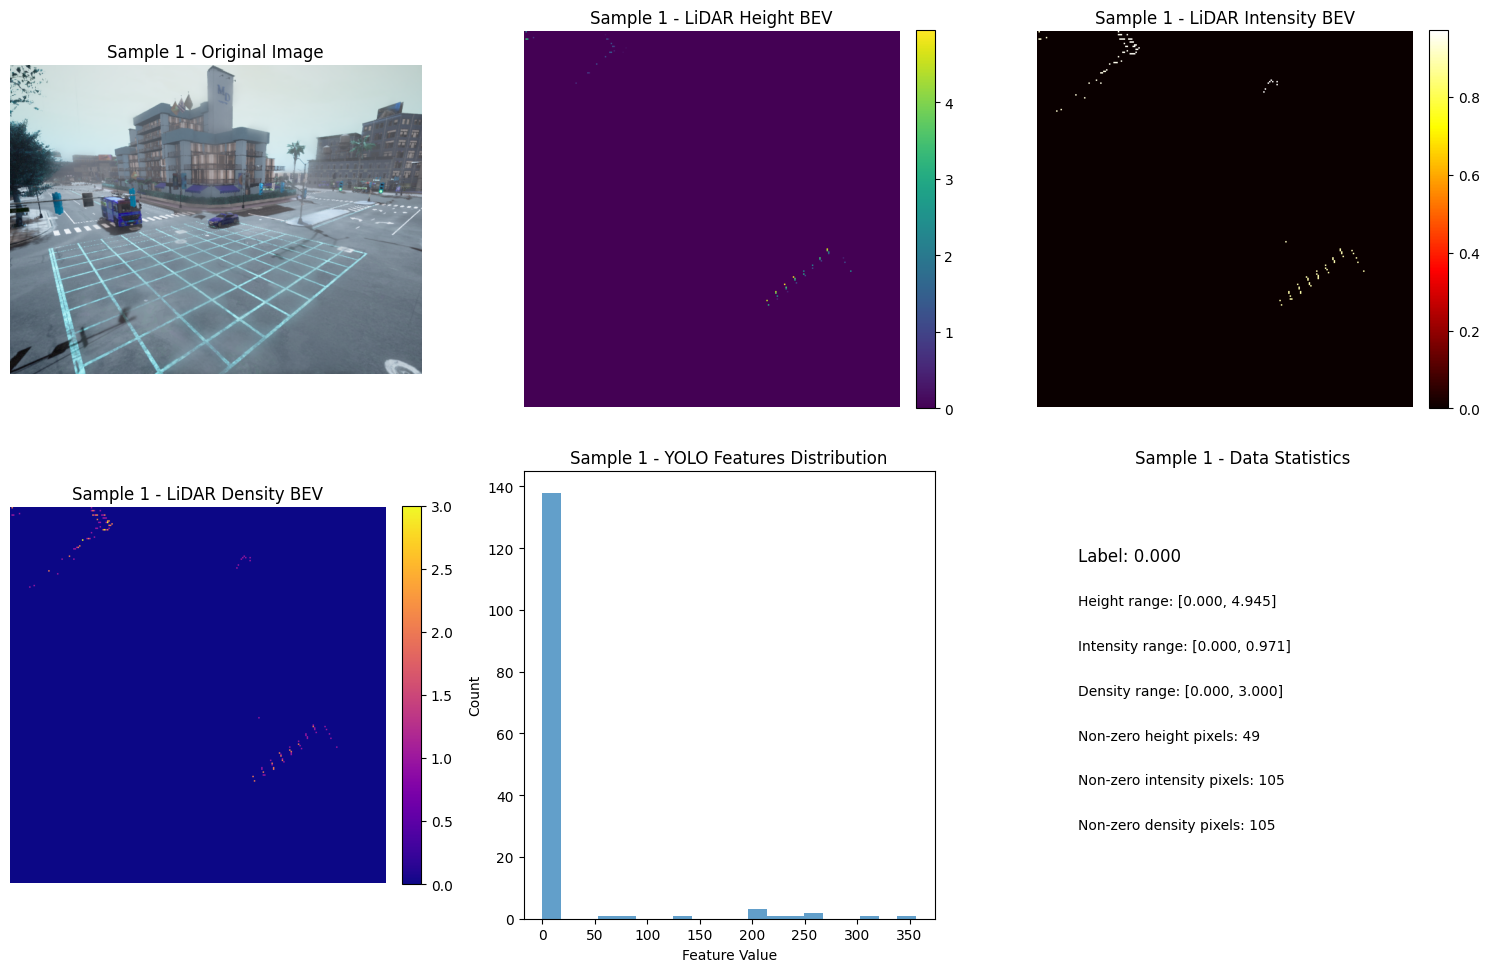

LiDAR Height - Min: 0.000, Max: 4.945, Non-zero: 49
LiDAR Intensity - Min: 0.000, Max: 0.971, Non-zero: 105
LiDAR Density - Min: 0.000, Max: 3.000, Non-zero: 105
YOLO Features - Min: 0.000, Max: 356.214, Non-zero: 18

--- Sample 2 ---
Image shape: torch.Size([3, 480, 640])
YOLO features shape: torch.Size([150])
LiDAR grid shape: torch.Size([3, 256, 256])
Label: 0.0


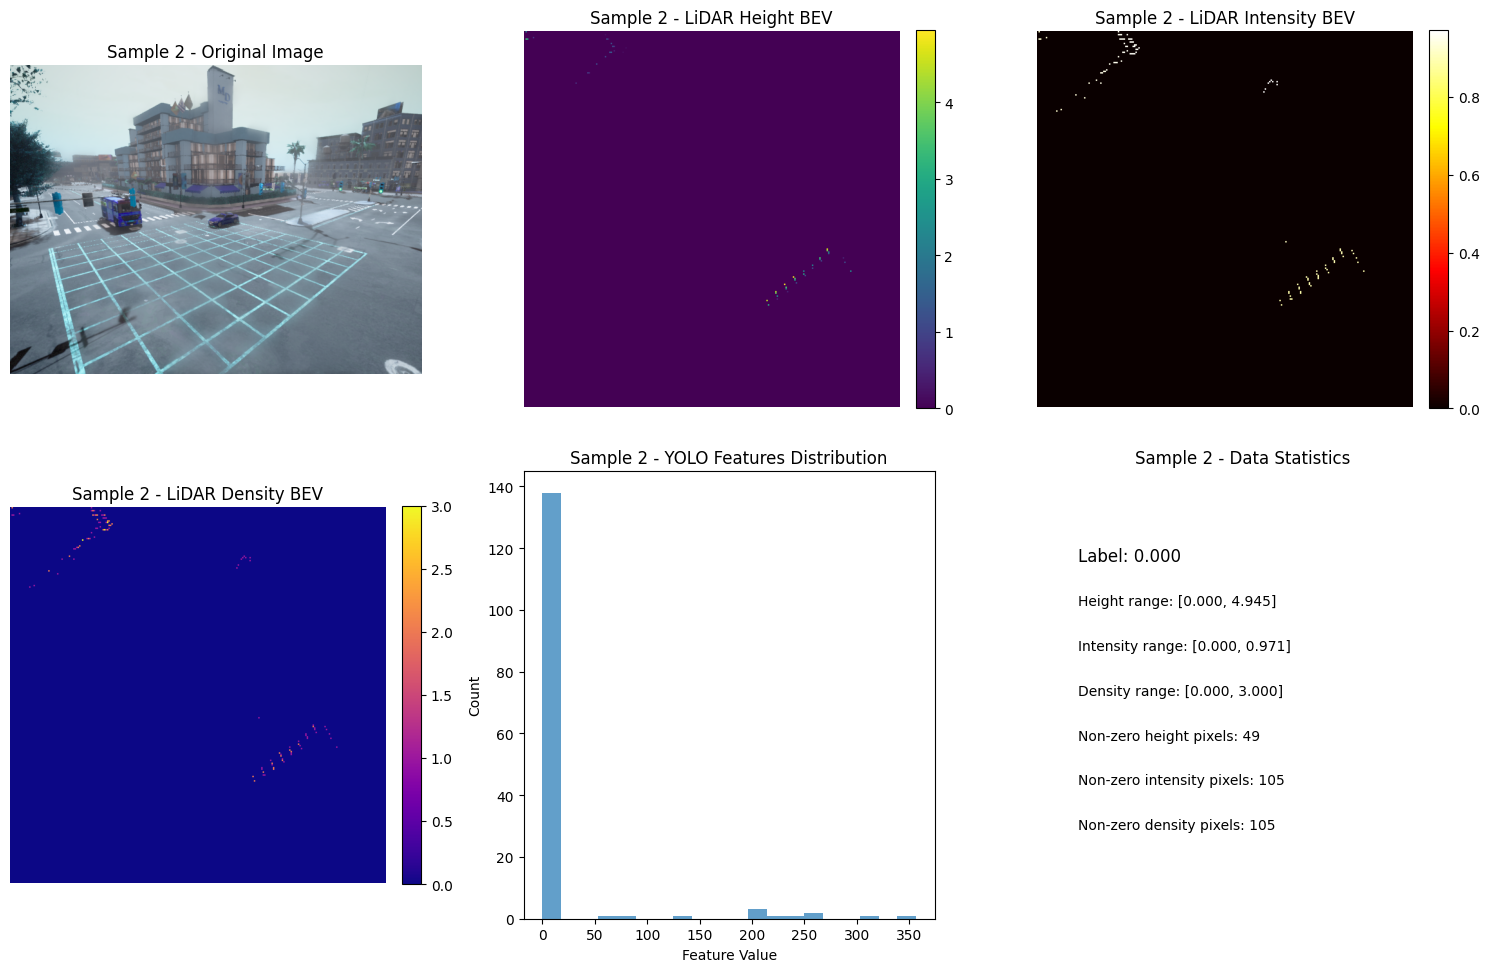

LiDAR Height - Min: 0.000, Max: 4.945, Non-zero: 49
LiDAR Intensity - Min: 0.000, Max: 0.971, Non-zero: 105
LiDAR Density - Min: 0.000, Max: 3.000, Non-zero: 105
YOLO Features - Min: 0.000, Max: 356.341, Non-zero: 18

VISUALIZING VALIDATION DATA SAMPLES

=== Data Visualization - Checking 1 samples ===

--- Sample 1 ---
Image shape: torch.Size([3, 480, 640])
YOLO features shape: torch.Size([150])
LiDAR grid shape: torch.Size([3, 256, 256])
Label: 0.0


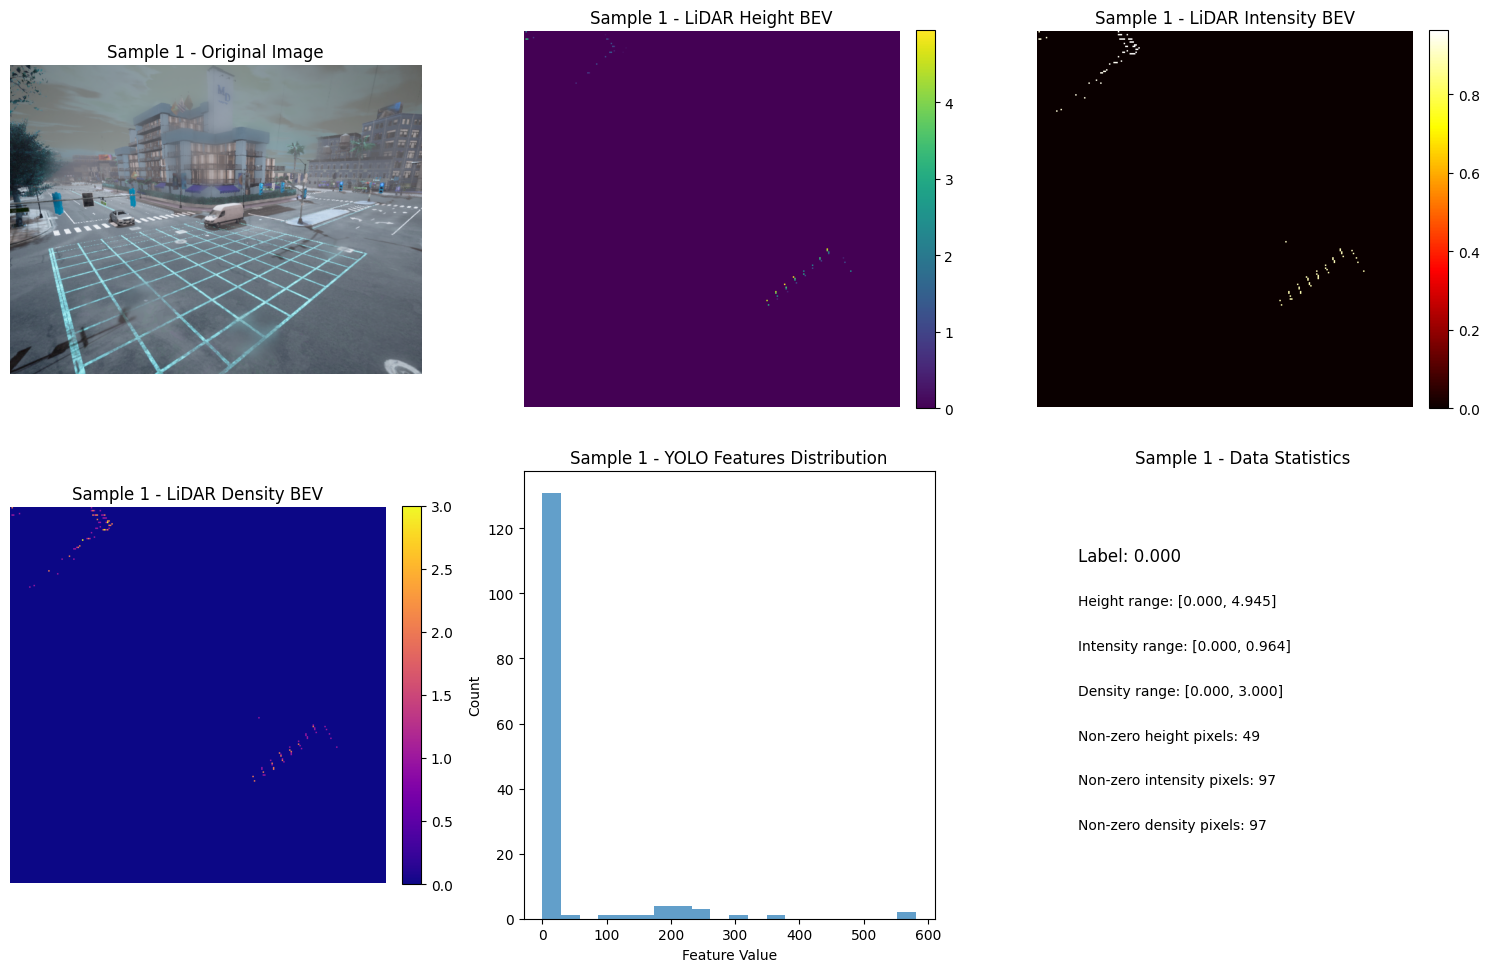

LiDAR Height - Min: 0.000, Max: 4.945, Non-zero: 49
LiDAR Intensity - Min: 0.000, Max: 0.964, Non-zero: 97
LiDAR Density - Min: 0.000, Max: 3.000, Non-zero: 97
YOLO Features - Min: 0.000, Max: 581.289, Non-zero: 30


In [10]:
# Quick data visualization function
def visualize_sample_data(dataset, num_samples=3):
    """Visualize a few samples from the dataset to check data quality"""
    print(f"\n=== Data Visualization - Checking {num_samples} samples ===")

    for i in range(min(num_samples, len(dataset))):
        print(f"\n--- Sample {i+1} ---")

        # Get sample
        if INCLUDE_LIDAR:
            image, yolo_features, lidar_grid, label = dataset[i]
            print(f"Image shape: {image.shape}")
            print(f"YOLO features shape: {yolo_features.shape}")
            print(f"LiDAR grid shape: {lidar_grid.shape}")
            print(f"Label: {label}")

            # Convert image tensor back to numpy for visualization
            if hasattr(image, 'numpy'):
                image_np = image.numpy().transpose(1, 2, 0)
            else:
                image_np = image

            # Convert LiDAR grid to numpy
            lidar_np = lidar_grid.numpy()

            # Create visualization
            fig, axes = plt.subplots(2, 3, figsize=(15, 10))

            # Original image
            axes[0, 0].imshow(np.clip(image_np, 0, 1))
            axes[0, 0].set_title(f'Sample {i+1} - Original Image')
            axes[0, 0].axis('off')

            # LiDAR height channel
            height_channel = lidar_np[0]  # Shape: (256, 256)
            im1 = axes[0, 1].imshow(height_channel, cmap='viridis', aspect='equal')
            axes[0, 1].set_title(f'Sample {i+1} - LiDAR Height BEV')
            axes[0, 1].axis('off')
            plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

            # LiDAR intensity channel
            intensity_channel = lidar_np[1]  # Shape: (256, 256)
            im2 = axes[0, 2].imshow(intensity_channel, cmap='hot', aspect='equal')
            axes[0, 2].set_title(f'Sample {i+1} - LiDAR Intensity BEV')
            axes[0, 2].axis('off')
            plt.colorbar(im2, ax=axes[0, 2], fraction=0.046, pad=0.04)

            # LiDAR density channel
            density_channel = lidar_np[2]  # Shape: (256, 256)
            im3 = axes[1, 0].imshow(density_channel, cmap='plasma', aspect='equal')
            axes[1, 0].set_title(f'Sample {i+1} - LiDAR Density BEV')
            axes[1, 0].axis('off')
            plt.colorbar(im3, ax=axes[1, 0], fraction=0.046, pad=0.04)

            # YOLO features histogram
            axes[1, 1].hist(yolo_features.numpy(), bins=20, alpha=0.7)
            axes[1, 1].set_title(f'Sample {i+1} - YOLO Features Distribution')
            axes[1, 1].set_xlabel('Feature Value')
            axes[1, 1].set_ylabel('Count')

            # Data statistics
            axes[1, 2].text(0.1, 0.8, f'Label: {label:.3f}', transform=axes[1, 2].transAxes, fontsize=12)
            axes[1, 2].text(0.1, 0.7, f'Height range: [{height_channel.min():.3f}, {height_channel.max():.3f}]', transform=axes[1, 2].transAxes, fontsize=10)
            axes[1, 2].text(0.1, 0.6, f'Intensity range: [{intensity_channel.min():.3f}, {intensity_channel.max():.3f}]', transform=axes[1, 2].transAxes, fontsize=10)
            axes[1, 2].text(0.1, 0.5, f'Density range: [{density_channel.min():.3f}, {density_channel.max():.3f}]', transform=axes[1, 2].transAxes, fontsize=10)
            axes[1, 2].text(0.1, 0.4, f'Non-zero height pixels: {np.count_nonzero(height_channel)}', transform=axes[1, 2].transAxes, fontsize=10)
            axes[1, 2].text(0.1, 0.3, f'Non-zero intensity pixels: {np.count_nonzero(intensity_channel)}', transform=axes[1, 2].transAxes, fontsize=10)
            axes[1, 2].text(0.1, 0.2, f'Non-zero density pixels: {np.count_nonzero(density_channel)}', transform=axes[1, 2].transAxes, fontsize=10)
            axes[1, 2].set_title(f'Sample {i+1} - Data Statistics')
            axes[1, 2].axis('off')

            plt.tight_layout()
            plt.show()

            # Print detailed statistics
            print(f"LiDAR Height - Min: {height_channel.min():.3f}, Max: {height_channel.max():.3f}, Non-zero: {np.count_nonzero(height_channel)}")
            print(f"LiDAR Intensity - Min: {intensity_channel.min():.3f}, Max: {intensity_channel.max():.3f}, Non-zero: {np.count_nonzero(intensity_channel)}")
            print(f"LiDAR Density - Min: {density_channel.min():.3f}, Max: {density_channel.max():.3f}, Non-zero: {np.count_nonzero(density_channel)}")
            print(f"YOLO Features - Min: {yolo_features.min():.3f}, Max: {yolo_features.max():.3f}, Non-zero: {torch.count_nonzero(yolo_features)}")

        else:
            image, yolo_features, label = dataset[i]
            print(f"Image shape: {image.shape}")
            print(f"YOLO features shape: {yolo_features.shape}")
            print(f"Label: {label}")

# Visualize some samples
print("\n" + "="*50)
print("VISUALIZING TRAINING DATA SAMPLES")
print("="*50)
visualize_sample_data(training_data, num_samples=2)

print("\n" + "="*50)
print("VISUALIZING VALIDATION DATA SAMPLES")
print("="*50)
visualize_sample_data(validation_data, num_samples=1)

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=1): # Change num_classes to 1 for binary classification with BCEWithLogitsLoss
        super(CustomCNN, self).__init__()
        # Image processing layers
        self.conv1_img = nn.Conv2d(IMG_CHS, CONV1_IMG, kernel_size=KERNAL_SIZE, padding=1)
        self.relu = nn.ReLU() # Added ReLU as a separate layer
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2_img = nn.Conv2d(CONV1_IMG, CONV2_IMG, kernel_size=KERNAL_SIZE, padding=1)
        # self.conv3_img = nn.Conv2d(CONV2_IMG, CONV3_IMG, kernel_size=KERNAL_SIZE, padding=1)
        self.apool_img = nn.AdaptiveAvgPool2d((8, 8))

        # Calculate the output size of the image convolutional layers after pooling
        # Assuming 2 pooling layers with kernel size 2
        # img_conv_output_width = IMG_WIDTH // 4
        # img_conv_output_height = IMG_HEIGHT // 4
        # img_conv_output_size = CONV2_IMG * img_conv_output_width * img_conv_output_height

        # LiDAR processing layers (using convolutional layers for 2D grid)
        # Assuming lidar_grid_tensor has shape (channels, height, width) from the dataset
        # The number of input channels for LiDAR will depend on what you store in the grid
        # (e.g., 3 for height, intensity, density)
        self.conv1_lidar = nn.Conv2d(LIDAR_CHS, CONV1_LIDAR, kernel_size=KERNAL_SIZE, padding=1)
        self.conv2_lidar = nn.Conv2d(CONV1_LIDAR, CONV2_LIDAR, kernel_size=KERNAL_SIZE, padding=1)
        # self.conv3_lidar = nn.Conv2d(CONV2_LIDAR, CONV3_LIDAR, kernel_size=KERNAL_SIZE, padding=1)
        self.apool_lidar = nn.AdaptiveAvgPool2d((8, 8))

        # Calculate the output size of the LiDAR convolutional layers after pooling
        # You'll need to know the dimensions of your LiDAR grid to calculate this correctly
        # Assuming a similar pooling structure as the image layers
        # Based on the HDF5Dataset modification, lidar_grid_width and lidar_grid_height are 256
        # lidar_conv_output_width = LIDAR_GRID_WIDTH // 4 # Assuming 2 pooling layers with kernel size 2
        # lidar_conv_output_height = LIDAR_GRID_HEIGHT // 4 # Assuming 2 pooling layers with kernel size 2
        # lidar_conv_output_size = CONV2_LIDAR * lidar_conv_output_width * lidar_conv_output_height


        # Use the global YOLO_FEATURE_SIZE variable
        # Not Processing with own Conv Layers due to dimensionality
        yolo_feature_size = YOLO_FEATURE_SIZE
        img_feat = CONV2_IMG * 8 * 8
        lidar_feat = CONV2_LIDAR * 8 * 8
        in_features = img_feat + lidar_feat + yolo_feature_size

        # Combined fully connected layers
        # The input size to the first fully connected layer is the sum of flattened image,
        # flattened LiDAR, and YOLO feature sizes.
        self.fc1 = nn.Linear(in_features, FC1_SIZE)
        self.drop1 = nn.Dropout(p=DROPOUT_PROB) # Added dropout
        self.fc2 = nn.Linear(FC1_SIZE, num_classes) # Output 1 neuron for binary classification

    def forward(self, image_input, yolo_input, lidar_input):
        # Process image input
        x = self.conv1_img(image_input)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2_img(x)
        x = self.relu(x)
        x = self.pool(x)

        # x = self.conv3_img(x)
        # x = self.relu(x)
        # x = self.pool(x)
        x = self.apool_img(x)

        x = x.view(x.size(0), -1) # Flatten the image features


        # Process LiDAR input
        z = self.conv1_lidar(lidar_input)
        z = self.relu(z)
        z = self.pool(z)

        z = self.conv2_lidar(z)
        z = self.relu(z)
        z = self.pool(z)

        # z = self.conv3_lidar(z)
        # z = self.relu(z)
        # z = self.pool(z)
        z = self.apool_lidar(z)

        z = z.view(z.size(0), -1) # Flatten the LiDAR features


        # Process YOLO input (Placeholder: Replace with actual YOLO processing)
        # For demonstration, let's assume yolo_input is already a flattened tensor of size yolo_feature_size
        y = yolo_input # Assuming yolo_input is already processed

        # Concatenate image, YOLO, and LiDAR features
        combined_features = torch.cat((x, y, z), dim=1)

        # Fully connected layers
        combined_features = self.fc1(combined_features)
        combined_features = self.drop1(combined_features) # Added dropout
        combined_features = self.relu(combined_features) # Added ReLU

        output = self.fc2(combined_features)

        return output

In [ ]:
# Instantiate CNN
# Ensure num_classes is 1 for BCEWithLogitsLoss as intended
model = CustomCNN(num_classes=1)

In [ ]:
# Defining Accuracy and Loss Arrays for Graphing over Epochs
train_acc_arr = np.empty(EPOCHS)
val_acc_arr = np.empty(EPOCHS)

train_loss_arr = np.empty(EPOCHS)
val_loss_arr = np.empty(EPOCHS)

In [ ]:
# Compile Model
model = torch.compile(model.to(PROCESSOR))

# Binary Classifier like BCELoss
loss_function = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

In [ ]:
# Used for Training and Validation
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

In [ ]:
def train():
    loss = 0
    accuracy = 0

    model.train()
    for i, (image_input, yolo_input, lidar_input, y) in enumerate(training_loader):
        print(f"Starting training batch {i}")
        # Move data to the specified device
        image_input = image_input.to(PROCESSOR)
        yolo_input = yolo_input.to(PROCESSOR)
        lidar_input = lidar_input.to(PROCESSOR) # Add LiDAR input
        # Target y needs to be float and have the same shape as the output (batch_size, 1)
        y = y.float().unsqueeze(1).to(PROCESSOR)

        # Start model forward pass
        output = model(image_input, yolo_input, lidar_input) # Pass LiDAR input to model
        # End model forward pass

        optimizer.zero_grad()
        # Calculating batch loss
        batch_loss = loss_function(output, y)

        # Start model backward pass
        batch_loss.backward()
        # end model backward pass

        # Applying optimizer step
        optimizer.step()

        loss += batch_loss.item()
        # For accuracy with BCEWithLogitsLoss, apply sigmoid and threshold
        predicted_probs = torch.sigmoid(output)
        predicted_classes = (predicted_probs > 0.5).float()
        # Ensure output and target are on CPU for accuracy calculation if needed
        correct = (predicted_classes.cpu() == y.cpu()).sum().item()
        accuracy += correct / BATCH_SIZE # Use BATCH_SIZE here, not total N

        # Add print statements to inspect output and target
        if i == 0: # Print for the first batch of each epoch
            print(f"Train Batch {i} - Output (first 5): {output.squeeze().cpu().detach().numpy()[:5]}")
            print(f"Train Batch {i} - Target (first 5): {y.squeeze().cpu().detach().numpy()[:5]}")
        print(f"Finished training batch {i}")


    # Average loss and accuracy over all batches
    avg_loss = loss / len(training_loader)
    avg_accuracy = accuracy / len(training_loader) # Accuracy was summed per batch

    print("Training Loss", avg_loss)
    print("Training Accuracy", avg_accuracy)

    # For graphing
    return avg_loss, avg_accuracy

In [ ]:
@torch.no_grad()
def validate():
    loss = 0
    accuracy = 0

    model.eval()
    with torch.no_grad():
        for i, (image_input, yolo_input, lidar_input, y) in enumerate(validation_loader):
            # Move data to the specified device
            image_input = image_input.to(PROCESSOR)
            yolo_input = yolo_input.to(PROCESSOR)
            lidar_input = lidar_input.to(PROCESSOR) # Add LiDAR input
            # Target y needs to be float and have the same shape as the output (batch_size, 1)
            y = y.float().unsqueeze(1).to(PROCESSOR)

            output = model(image_input, yolo_input, lidar_input) # Pass LiDAR input to model

            loss += loss_function(output, y).item()
            # For accuracy with BCEWithLogitsLoss, apply sigmoid and threshold
            predicted_probs = torch.sigmoid(output)
            predicted_classes = (predicted_probs > 0.5).float()
            # Ensure output and target are on CPU for accuracy calculation if needed
            correct = (predicted_classes.cpu() == y.cpu()).sum().item()
            accuracy += correct / BATCH_SIZE # Use BATCH_SIZE here, not total N

            # Add print statements to inspect output and target
            if i == 0: # Print for the first batch of each epoch
                print(f"Validation Batch {i} - Output (first 5): {output.squeeze().cpu().detach().numpy()[:5]}")
                print(f"Validation Batch {i} - Target (first 5): {y.squeeze().cpu().detach().numpy()[:5]}")


    # Average loss and accuracy over all batches
    avg_loss = loss / len(validation_loader)
    avg_accuracy = accuracy / len(validation_loader) # Accuracy was summed per batch

    print("Validation Loss", avg_loss)
    print("Validation Accuracy", avg_accuracy)

    # For graphing
    return avg_loss, avg_accuracy

In [ ]:
# Run Model
%%time

# Add gradient clipping
clip_value = 1.0 # You can adjust this value

for epoch in range(EPOCHS):
    print('Epoch', epoch)

    # Call the train function
    train_loss_arr[epoch], train_acc_arr[epoch] = train()

    # Call the validate function
    val_loss_arr[epoch], val_acc_arr[epoch] = validate()

    print(f'Epoch {epoch+1}, Train Loss: {train_loss_arr[epoch]:.4f}, Train Acc: {train_acc_arr[epoch]:.4f}, Val Loss: {val_loss_arr[epoch]:.4f}, Val Acc: {val_acc_arr[epoch]:.4f}')


    # Save model
    if (epoch + 1 == EPOCHS): # Save Final
        torch.save(model.state_dict(), 'Demo2_Test_Final.pt')
    elif (epoch + 1) % SAVE_FREQ == 0: # Save partially through
        torch.save(model.state_dict(), f'Demo2_Test_epoch_{epoch+1}.pt')

Epoch 0
Starting training batch 0


/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:282: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


Train Batch 0 - Output (first 5): [-1.1615658  -2.584568   -1.4927971  -0.80379415  0.42891973]
Train Batch 0 - Target (first 5): [0. 0. 0. 0. 0.]
Finished training batch 0
Starting training batch 1
Finished training batch 1
Starting training batch 2
Finished training batch 2
Starting training batch 3
Finished training batch 3
Starting training batch 4
Finished training batch 4
Starting training batch 5
Finished training batch 5
Starting training batch 6
Finished training batch 6
Starting training batch 7
Finished training batch 7
Starting training batch 8
Finished training batch 8
Starting training batch 9
Finished training batch 9
Starting training batch 10
Finished training batch 10
Starting training batch 11
Finished training batch 11
Starting training batch 12
Finished training batch 12
Starting training batch 13
Finished training batch 13
Starting training batch 14
Finished training batch 14
Starting training batch 15
Finished training batch 15
Starting training batch 16
Finished

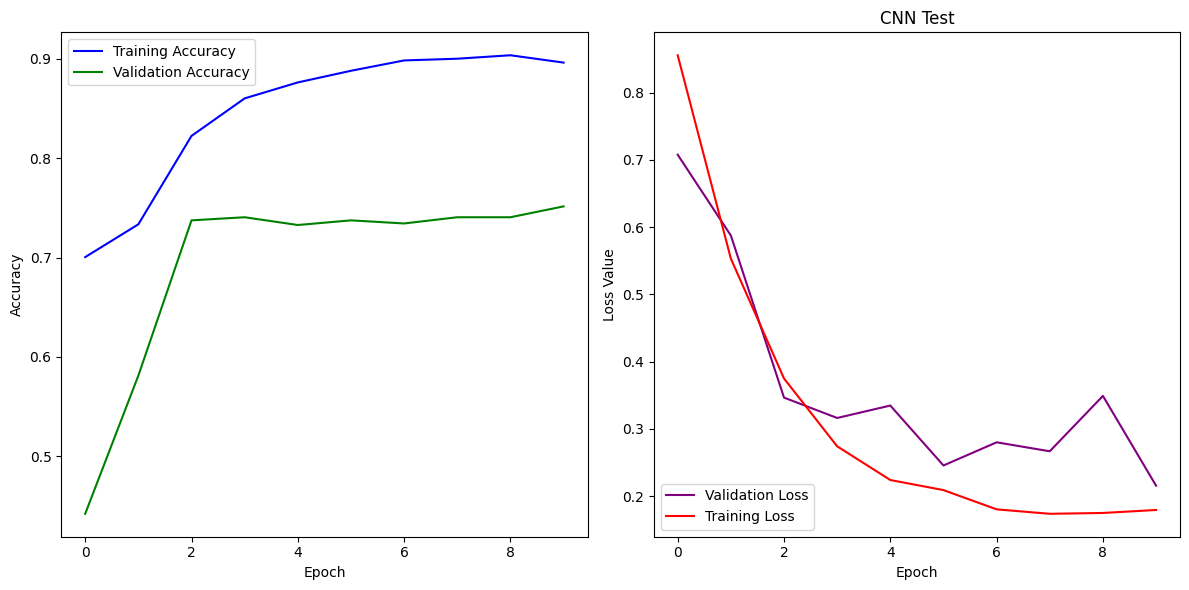

In [ ]:
# Plot our model's training
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].plot(range(EPOCHS), train_acc_arr, label='Training Accuracy', color='blue')
axs[0].plot(range(EPOCHS), val_acc_arr, label='Validation Accuracy', color='green')
axs[0].legend(loc="upper left")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Accuracy")

axs[1].plot(range(EPOCHS), val_loss_arr, label='Validation Loss', color='purple')
axs[1].plot(range(EPOCHS), train_loss_arr, label='Training Loss', color='red')
axs[1].legend(loc="lower left")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Loss Value")

plt.title("CNN Test")
plt.tight_layout()
plt.show()

In [ ]:
# # creating instance of model
# new_model = CustomCNN(num_classes=1)
# new_model = torch.compile(new_model)

# # loading weights from files
# new_model.load_state_dict(torch.load('/content/drive/My Drive/MVP1/Demo1_Test_epoch_5.pt'))
# new_model.eval()